# Bot Clustering Analysis
Combines the 5 hardcoded human player profiles with the newly parsed RL bot profiles, performs EDA (radar charts), then applies K-Means clustering with PCA visualization to determine which hardcoded profile the RL bot most closely resembles.

In [13]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

# Load hardcoded human profiles (5 players from original EDA)
human_path = Path('../../data/player_profiles/player_profiles.parquet')
df_human = pl.read_parquet(human_path)

# Load newly parsed RL bot profiles
rl_path = Path('../../data/player_profiles/parsed_eval_logs_profiles.parquet')
df_rl = pl.read_parquet(rl_path)

# Unify column name: 'player' -> 'bot_name'
df_human = df_human.rename({'player': 'bot_name'})

print(f'Human profiles: {df_human.shape}')
print(f'RL bot profiles: {df_rl.shape}')

# Combine into a single DataFrame
df = pl.concat([df_human, df_rl], how='diagonal')
print(f'Combined profiles: {df.shape}')
print(f'Bots: {df["bot_name"].to_list()}')

# Convert to pandas for plotting
plot_df = df.to_pandas()


Human profiles: (5, 19)
RL bot profiles: (1, 19)
Combined profiles: (6, 19)
Bots: ['HomeofAD3005', 'AatNeverLose', 'Romeoore', 'ZL24', 'UniQueLagacy', 'aware_axelrod']


In [14]:
# Quick overview: describe + schema
print('\n=== COMBINED DATASET ===')
print(f'Shape: {df.shape}')
print(f'Columns: {len(df.columns)}')
print('\nSchema:')
for col_name, dtype in df.schema.items():
    print(f'  - {col_name}: {dtype}')

print('\nSummary stats:')
print(df.describe())



=== COMBINED DATASET ===
Shape: (6, 19)
Columns: 19

Schema:
  - bot_name: String
  - num_games: UInt32
  - avg_turns_before_first_trade: Float64
  - ratio_cards_given_to_taken: Float64
  - trade_success_rate: Float64
  - avg_counter_offers: Float64
  - avg_bank_trades: Float64
  - avg_dev_cards_bought: Float64
  - avg_roads_built: Float64
  - avg_cities_built: Float64
  - avg_players_targeted: Float64
  - avg_times_targeted: Float64
  - win_rate_largest_army: Float64
  - win_rate_longest_road: Float64
  - average_games_with_port_used: Float64
  - overall_avg_hand_size: Float64
  - top_3_starting_resources: String
  - most_traded_away_resource: String
  - most_received_resource: String

Summary stats:
shape: (9, 20)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ bot_name  ┆ num_games ┆ avg_turns ┆ … ┆ overall_a ┆ top_3_sta ┆ most_trad ┆ most_rec │
│ ---       ┆ ---       ┆ ---       ┆ _before_f ┆   ┆ vg_hand_s ┆ rting

In [15]:
# Check for missing values
print('\n=== MISSING VALUES (NULL) ===')
null_counts = df.null_count().transpose(include_header=True, header_name='column', column_names=['null_count'])
print(null_counts.sort('null_count', descending=True))

print('\n=== MISSING VALUES (NaN) ===')
float_cols = [c for c, dt in df.schema.items() if dt in (pl.Float32, pl.Float64)]
if float_cols:
    nan_counts = df.select([
        pl.col(c).is_nan().sum().alias(c) for c in float_cols
    ]).transpose(include_header=True, header_name='column', column_names=['nan_count'])
    print(nan_counts.sort('nan_count', descending=True))



=== MISSING VALUES (NULL) ===
shape: (19, 2)
┌──────────────────────────────┬────────────┐
│ column                       ┆ null_count │
│ ---                          ┆ ---        │
│ str                          ┆ u32        │
╞══════════════════════════════╪════════════╡
│ bot_name                     ┆ 0          │
│ num_games                    ┆ 0          │
│ avg_turns_before_first_trade ┆ 0          │
│ ratio_cards_given_to_taken   ┆ 0          │
│ trade_success_rate           ┆ 0          │
│ …                            ┆ …          │
│ average_games_with_port_used ┆ 0          │
│ overall_avg_hand_size        ┆ 0          │
│ top_3_starting_resources     ┆ 0          │
│ most_traded_away_resource    ┆ 0          │
│ most_received_resource       ┆ 0          │
└──────────────────────────────┴────────────┘

=== MISSING VALUES (NaN) ===
shape: (14, 2)
┌──────────────────────────────┬───────────┐
│ column                       ┆ nan_count │
│ ---                          ┆ --- 

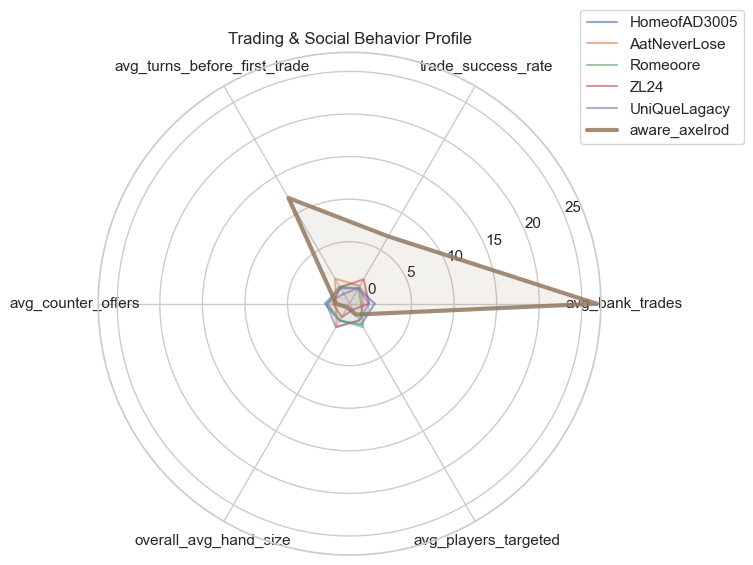

In [16]:
# Radar Chart 1: Trading & Social Behavior
radar_metrics_trading = [
    'avg_bank_trades',
    'trade_success_rate',
    'avg_turns_before_first_trade',
    'avg_counter_offers',
    'overall_avg_hand_size',
    'avg_players_targeted'
]

available = [m for m in radar_metrics_trading if m in plot_df.columns]
if available:
    # Robust-scale each metric across all bots
    radar_df = plot_df[['bot_name'] + available].copy()
    for metric in available:
        q1 = radar_df[metric].quantile(0.25)
        q3 = radar_df[metric].quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            radar_df[f'{metric}__norm'] = 0.0
        else:
            radar_df[f'{metric}__norm'] = (radar_df[metric] - radar_df[metric].median()) / iqr

    norm_metrics = [f'{m}__norm' for m in available]
    angles = np.linspace(0, 2 * np.pi, len(available), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for _, row in radar_df.iterrows():
        values = [row[m] for m in norm_metrics]
        values += values[:1]
        # Highlight RL bots with thicker lines
        is_rl = row['bot_name'].startswith(('baseline', 'aware', 'shuffled'))
        lw = 3 if is_rl else 1.5
        alpha = 0.85 if is_rl else 0.6
        ax.plot(angles, values, linewidth=lw, alpha=alpha, label=row['bot_name'])
        ax.fill(angles, values, alpha=0.1 if is_rl else 0.05)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(available)

    all_vals = radar_df[norm_metrics].values
    ax.set_ylim(np.nanmin(all_vals) - 0.5, np.nanmax(all_vals) + 0.5)

    ax.set_title('Trading & Social Behavior Profile')
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()


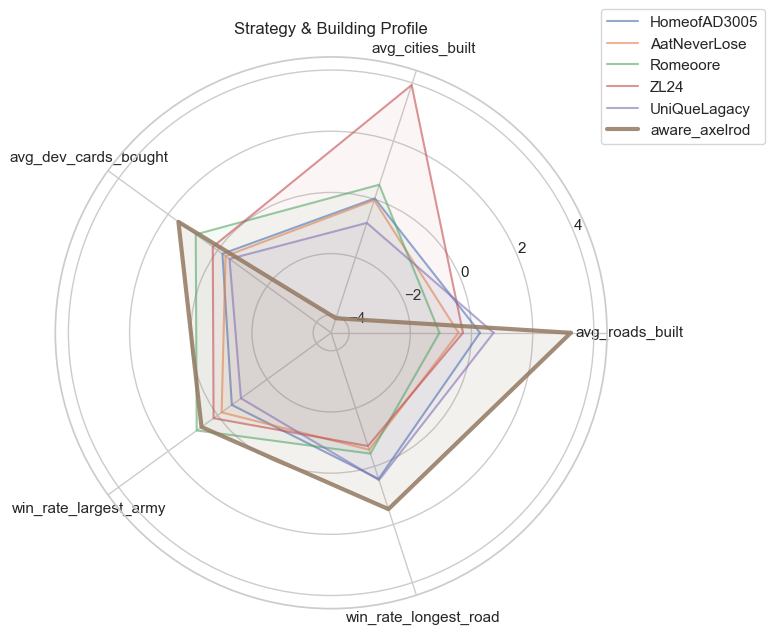

In [17]:
# Radar Chart 2: Strategy & Building Behavior
radar_metrics_strategy = [
    'avg_roads_built',
    'avg_cities_built',
    'avg_dev_cards_bought',
    'win_rate_largest_army',
    'win_rate_longest_road'
]

available = [m for m in radar_metrics_strategy if m in plot_df.columns]
if available:
    radar_df = plot_df[['bot_name'] + available].copy()
    for metric in available:
        q1 = radar_df[metric].quantile(0.25)
        q3 = radar_df[metric].quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            radar_df[f'{metric}__norm'] = 0.0
        else:
            radar_df[f'{metric}__norm'] = (radar_df[metric] - radar_df[metric].median()) / iqr

    norm_metrics = [f'{m}__norm' for m in available]
    angles = np.linspace(0, 2 * np.pi, len(available), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for _, row in radar_df.iterrows():
        values = [row[m] for m in norm_metrics]
        values += values[:1]
        is_rl = row['bot_name'].startswith(('baseline', 'aware', 'shuffled'))
        lw = 3 if is_rl else 1.5
        alpha = 0.85 if is_rl else 0.6
        ax.plot(angles, values, linewidth=lw, alpha=alpha, label=row['bot_name'])
        ax.fill(angles, values, alpha=0.1 if is_rl else 0.05)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(available)

    all_vals = radar_df[norm_metrics].values
    ax.set_ylim(np.nanmin(all_vals) - 0.5, np.nanmax(all_vals) + 0.5)

    ax.set_title('Strategy & Building Profile')
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()


In [18]:
# ML-ready feature engineering (same pipeline as eda.ipynb)
exclude_from_features = {'bot_name', 'avg_cards_discarded_to_7'}
feature_cols = [c for c in df.columns if c not in exclude_from_features]

numeric_cols = [
    c for c in feature_cols
    if df.schema[c] in (
        pl.Int8, pl.Int16, pl.Int32, pl.Int64,
        pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
        pl.Float32, pl.Float64
    )
]

categorical_cols = [
    c for c in feature_cols
    if df.schema[c] in (pl.Utf8, pl.Categorical)
]

print(f'Numeric columns ({len(numeric_cols)}): {numeric_cols}')
print(f'Categorical columns ({len(categorical_cols)}): {categorical_cols}')

# Impute numeric nulls with median
if numeric_cols:
    numeric_impute_exprs = [
        pl.when(pl.col(c).is_null())
          .then(pl.col(c).median())
          .otherwise(pl.col(c))
          .alias(c)
        for c in numeric_cols
    ]
    df_clean = df.with_columns(numeric_impute_exprs)
else:
    df_clean = df

# Impute categorical nulls with 'Unknown'
if categorical_cols:
    cat_impute_exprs = [pl.col(c).fill_null('Unknown').alias(c) for c in categorical_cols]
    df_clean = df_clean.with_columns(cat_impute_exprs)

# Build ML dataframe
df_ml = df_clean.select(['bot_name'] + numeric_cols + categorical_cols)

# Handle top_3_starting_resources as multi-label binary flags
resource_list_col = 'top_3_starting_resources'
if resource_list_col in df_ml.columns:
    resource_values = ['ore', 'wool', 'lumber', 'grain', 'brick']
    resource_exprs = [
        pl.when(
            pl.col(resource_list_col)
              .str.to_lowercase()
              .str.contains(rf'(^|,\s*){res}(\s*,|$)')
        )
        .then(1)
        .otherwise(0)
        .alias(f'starting_resource_{res}')
        for res in resource_values
    ]
    df_ml = df_ml.with_columns(resource_exprs).drop(resource_list_col)

# One-hot encode remaining categorical columns
remaining_cat = [c for c in categorical_cols if c != resource_list_col and c in df_ml.columns]
if remaining_cat:
    df_ml = df_ml.to_dummies(columns=remaining_cat, separator='__')

# Z-score standardize all numeric columns
ml_numeric_cols = [
    c for c, dt in df_ml.schema.items()
    if c != 'bot_name' and dt in (
        pl.Int8, pl.Int16, pl.Int32, pl.Int64,
        pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
        pl.Float32, pl.Float64
    )
]

scaled_exprs = []
for c in ml_numeric_cols:
    mean_expr = pl.col(c).mean()
    std_expr = pl.col(c).std()
    scaled_exprs.append(
        pl.when(std_expr.is_null() | (std_expr == 0))
          .then(0.0)
          .otherwise((pl.col(c) - mean_expr) / std_expr)
          .alias(f'{c}__z')
    )

df_ml_ready = df_ml.with_columns(scaled_exprs)
print(f'\nML-ready shape: {df_ml_ready.shape}')


Numeric columns (15): ['num_games', 'avg_turns_before_first_trade', 'ratio_cards_given_to_taken', 'trade_success_rate', 'avg_counter_offers', 'avg_bank_trades', 'avg_dev_cards_bought', 'avg_roads_built', 'avg_cities_built', 'avg_players_targeted', 'avg_times_targeted', 'win_rate_largest_army', 'win_rate_longest_road', 'average_games_with_port_used', 'overall_avg_hand_size']
Categorical columns (3): ['top_3_starting_resources', 'most_traded_away_resource', 'most_received_resource']

ML-ready shape: (6, 53)


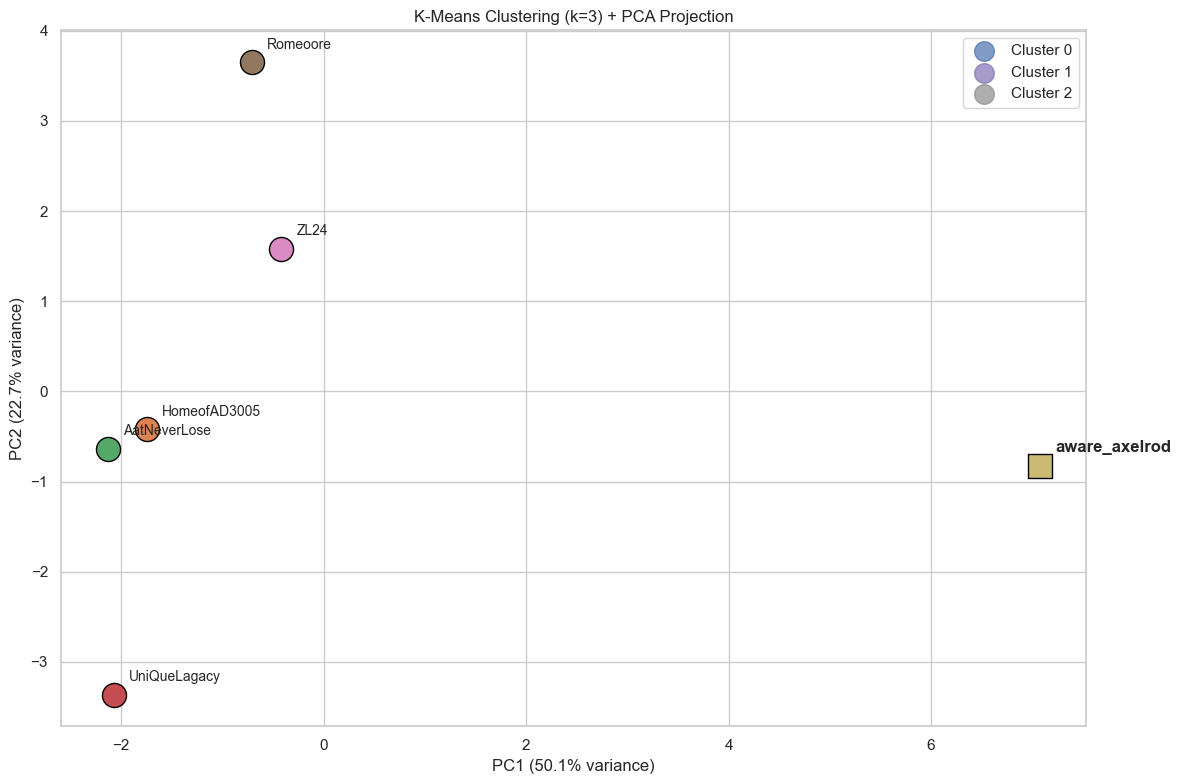


Cluster assignments:
  HomeofAD3005 -> Cluster 0
  AatNeverLose -> Cluster 0
  Romeoore -> Cluster 1
  ZL24 -> Cluster 1
  UniQueLagacy -> Cluster 0
  aware_axelrod [RL BOT] -> Cluster 2


In [19]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd

# Extract z-scored features for clustering (exclude bot_name)
z_cols = [c for c in df_ml_ready.columns if c.endswith('__z')]
if not z_cols:
    z_cols = ml_numeric_cols

X = df_ml_ready.select(z_cols).to_numpy()
bot_names = df_ml_ready['bot_name'].to_list()

# K-Means clustering (k=3: aggressive traders, builders, passive)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# Plot clusters
plt.figure(figsize=(12, 8))

for cluster_id in range(3):
    mask = labels == cluster_id
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                label=f'Cluster {cluster_id}', s=200, alpha=0.7)

    for i in np.where(mask)[0]:
        name = bot_names[i]
        is_rl = name.startswith(('baseline', 'aware', 'shuffled'))
        marker = 's' if is_rl else 'o'
        fontsize = 12 if is_rl else 10
        weight = 'bold' if is_rl else 'normal'
        plt.scatter(X_2d[i, 0], X_2d[i, 1],
                   marker=marker, s=300, edgecolor='black', zorder=5)
        plt.text(X_2d[i, 0] + 0.15, X_2d[i, 1] + 0.15,
                name, fontsize=fontsize, weight=weight, zorder=6)

plt.title('K-Means Clustering (k=3) + PCA Projection')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend()
plt.tight_layout()
plt.savefig('../../data/player_profiles/bot_clusters.png', dpi=150)
plt.show()

# Print cluster assignments
print('\nCluster assignments:')
for i, name in enumerate(bot_names):
    tag = ' [RL BOT]' if name.startswith(('baseline', 'aware', 'shuffled')) else ''
    print(f'  {name}{tag} -> Cluster {labels[i]}')


In [20]:
# Determine which hardcoded profile each RL bot most closely resembles
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

human_names = [n for n in bot_names if not n.startswith(('baseline', 'aware', 'shuffled'))]
rl_names = [n for n in bot_names if n.startswith(('baseline', 'aware', 'shuffled'))]

name_to_idx = {name: i for i, name in enumerate(bot_names)}

print('=== SIMILARITY ANALYSIS (Euclidean distance in feature space) ===')
for rl_name in rl_names:
    rl_idx = name_to_idx[rl_name]
    distances = {}
    for h_name in human_names:
        h_idx = name_to_idx[h_name]
        dist = np.linalg.norm(X[rl_idx] - X[h_idx])
        distances[h_name] = dist

    closest = min(distances, key=distances.get)
    print(f'\n{rl_name}:')
    for h_name, dist in sorted(distances.items(), key=lambda x: x[1]):
        marker = ' <-- CLOSEST' if h_name == closest else ''
        print(f'  {h_name}: distance = {dist:.4f}{marker}')
    print(f'\n>> {rl_name} most closely resembles: {closest}')


=== SIMILARITY ANALYSIS (Euclidean distance in feature space) ===

aware_axelrod:
  ZL24: distance = 8.5113 <-- CLOSEST
  HomeofAD3005: distance = 9.1614
  Romeoore: distance = 9.2642
  AatNeverLose: distance = 9.6153
  UniQueLagacy: distance = 9.7634

>> aware_axelrod most closely resembles: ZL24
